In [7]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
from torchvision import transforms
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import wandb


In [8]:
NUM_CLASSES = 7
BATCH_SIZE = 32  # Changed from 127
LEARNING_RATE = 2e-4  # Adjusted for 50 epochs
EPOCHS_NUM = 50

run = wandb.init(
    project="classification-model-comparison",
    config={
        "batch_size": BATCH_SIZE,
        "num_classes": NUM_CLASSES,
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS_NUM,
        "model":"custom",
    }
)


In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

augmentation_transforms = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomResizedCrop(size=64, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.512, 0.433, 0.389], std=[0.210, 0.185, 0.162])
])

test_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset_full = ImageFolder(
    root='C:/Diploma/classification_dataset',
    transform=augmentation_transforms  # Застосовуємо train_transforms
)

test_dataset_full = ImageFolder(
    root='C:/Diploma/classification_dataset',
    transform=test_transforms  # Застосовуємо test_transforms
)

# 4. Отримуємо labels для стратифікації
labels = [label for _, label in train_dataset_full]

# 5. Створюємо індекси для розділення
train_indices, test_indices = train_test_split(
    range(len(train_dataset_full)),
    test_size=0.15,
    stratify=labels,
    random_state=42
)

# 6. Створюємо підмножини
train_dataset = Subset(train_dataset_full, train_indices)
test_dataset = Subset(test_dataset_full, test_indices)

# 7. Створюємо завантажувачі даних
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
# test_dataset.dataset.transform = test_transforms

# 9. Print dataset information
print(f"Classes: {train_dataset_full.classes}")
print(f"Total samples: {len(train_dataset_full)}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k']
Total samples: 14317
Training samples: 12169
Testing samples: 2148



Displaying first 10 samples from Training Dataset:


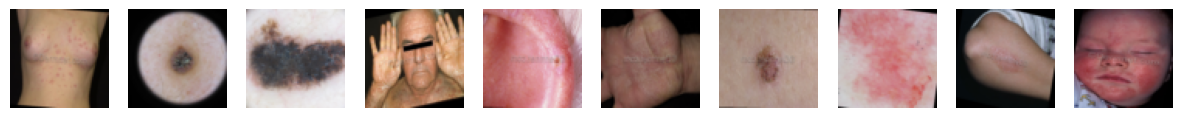

Class Labels Mapping: {5: '7. Psoriasis pictures Lichen Planus and related diseases - 2k', 4: '6. Benign Keratosis-like Lesions (BKL) 2624', 6: '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', 3: '4. Basal Cell Carcinoma (BCC) 3323', 2: '3. Atopic Dermatitis - 1.25k'}

Displaying first 10 samples from Testing Dataset:


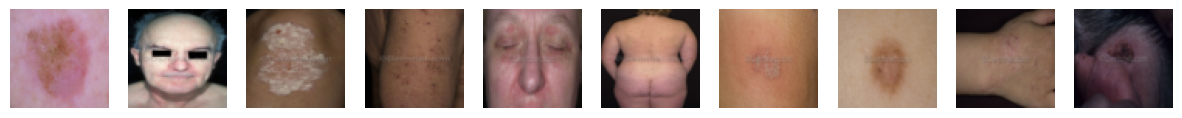

Class Labels Mapping: {5: '7. Psoriasis pictures Lichen Planus and related diseases - 2k', 4: '6. Benign Keratosis-like Lesions (BKL) 2624', 6: '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', 3: '4. Basal Cell Carcinoma (BCC) 3323', 2: '3. Atopic Dermatitis - 1.25k', 1: '10. Warts Molluscum and other Viral Infections - 2103'}


In [10]:
import matplotlib.pyplot as plt

print("\nDisplaying first 10 samples from Training Dataset:")
plt.figure(figsize=(15, 5))

class_labels = {}

for i in range(10):
    image, label = train_dataset[i]  
    class_labels[label] = train_dataset.dataset.classes[label]

    plt.subplot(1, 10, i + 1)
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Нормалізація в діапазон [0,1]
    plt.axis('off')

plt.show()
print("Class Labels Mapping:", class_labels)

print("\nDisplaying first 10 samples from Testing Dataset:")
plt.figure(figsize=(15, 5))

for i in range(10):
    image, label = test_dataset[i]
    class_labels[label] = test_dataset.dataset.classes[label]

    plt.subplot(1, 10, i + 1)
    plt.imshow(image.permute(1, 2, 0).clamp(0, 1).numpy())  # Нормалізація в діапазон [0,1]
    plt.axis('off') 

plt.show()
print("Class Labels Mapping:", class_labels)


In [11]:
from NN_class import ConvNeuralNet

model = ConvNeuralNet(NUM_CLASSES)

class_counts = [1677, 2103, 1250, 3323, 2624, 2000, 1800]
total_samples = sum(class_counts)
class_weights = torch.FloatTensor([total_samples/(len(class_counts)*count) for count in class_counts]).to(device)

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,
    betas=(0.9, 0.999)
)

In [12]:
from utils import evaluate, train


def train_model(model, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        train_loss, train_acc, train_prec, train_rec, train_f1 = train(model, criterion, optimizer,device,train_loader)
        eval_acc, eval_prec, eval_rec, eval_f1 = evaluate(model,device,test_loader)

        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, Prec: {train_prec:.4f}, Rec: {train_rec:.4f},F1: {train_f1:.4f}")
        wandb.log({
                "Training/Loss": train_loss,
                "Training/Accuracy": train_acc,
                "Training/Precision": train_prec,
                "Training/Recall": train_rec,
                "Training/F1_Score": train_f1
            })

        print(f"Eval  - Acc: {eval_acc:.4f}, Prec: {eval_prec:.4f}, Rec: {eval_rec:.4f}, F1: {eval_f1:.4f}")
        wandb.log({
        "Evaluation/Accuracy": eval_acc,
        "Evaluation/Precision": eval_prec,
        "Evaluation/Recall": eval_rec,
        "Evaluation/F1_Score": eval_f1
    })

    return model

model = train_model(model, criterion, optimizer, EPOCHS_NUM)


Epoch [1/50]
Train - Loss: 1.6850, Acc: 0.3285, Prec: 0.3347, Rec: 0.3285,F1: 0.3293
Eval  - Acc: 0.4013, Prec: 0.4110, Rec: 0.4013, F1: 0.3906
Epoch [2/50]
Train - Loss: 1.5107, Acc: 0.4092, Prec: 0.4124, Rec: 0.4092,F1: 0.4086
Eval  - Acc: 0.4553, Prec: 0.4703, Rec: 0.4553, F1: 0.4526
Epoch [3/50]
Train - Loss: 1.4224, Acc: 0.4404, Prec: 0.4427, Rec: 0.4404,F1: 0.4388
Eval  - Acc: 0.4935, Prec: 0.4863, Rec: 0.4935, F1: 0.4869
Epoch [4/50]
Train - Loss: 1.3746, Acc: 0.4679, Prec: 0.4683, Rec: 0.4679,F1: 0.4664
Eval  - Acc: 0.4674, Prec: 0.4421, Rec: 0.4674, F1: 0.4394
Epoch [5/50]
Train - Loss: 1.3316, Acc: 0.4754, Prec: 0.4771, Rec: 0.4754,F1: 0.4735
Eval  - Acc: 0.5298, Prec: 0.5325, Rec: 0.5298, F1: 0.5256
Epoch [6/50]
Train - Loss: 1.2999, Acc: 0.4968, Prec: 0.4975, Rec: 0.4968,F1: 0.4949
Eval  - Acc: 0.5154, Prec: 0.5029, Rec: 0.5154, F1: 0.4990
Epoch [7/50]
Train - Loss: 1.2653, Acc: 0.5152, Prec: 0.5177, Rec: 0.5152,F1: 0.5137
Eval  - Acc: 0.5177, Prec: 0.5166, Rec: 0.5177, F1:

Final Accuracy on 2148 test images: 68.30 %


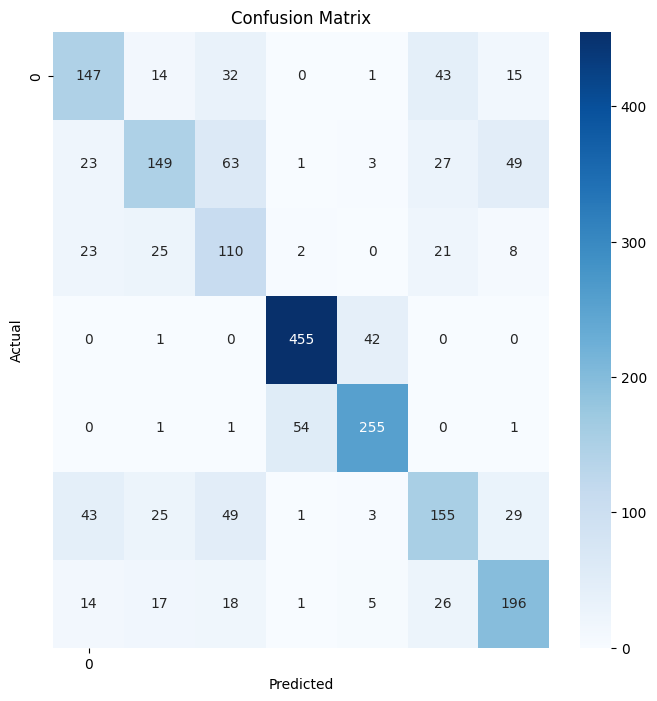

In [13]:
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from NN_class import ConvNeuralNet
import torch

model.eval()
correct = 0
total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct / total
print(f'Final Accuracy on {len(test_dataset)} test images: {accuracy:.2f} %')


# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Логування у wandb (якщо потрібно)
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=NUM_CLASSES, yticklabels=NUM_CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
wandb.log({"confusion_matrix": wandb.Image(fig)})
plt.close()

In [14]:
torch.save(model.state_dict(), "../files/custom_classification_model.pth")
print("Model saved as 'classification_model.pth'")
wandb.finish()

Model saved as 'classification_model.pth'


Evaluation/Accuracy,▁▂▁▁▁▁▁▁▂▂▂▁▄▅▆▆▆▆▆▇▇▇▇▇▇▇█▇████████▇███
Evaluation/F1_Score,▁▁▂▁▁▁▂▃▂▂▂▂▅▆▅▇▆▇▆▇▇▇▇▇▇▇▇▇█▇█████▇████
Evaluation/Precision,▁▁▁▂▂▂▂▄▃▃▆▆▆▆▇▆▇▇▇▇▇█▇▇████████████████
Evaluation/Recall,▁▂▁▂▁▁▁▁▁▁▂▁▂▁▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇███████████
Training/Accuracy,▁▃▃▄▄▅▅▅▅▆▆▆▆▁▃▄▄▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████
Training/F1_Score,▁▂▃▄▄▅▅▅▅▅▂▂▂▃▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████
Training/Loss,▆▆▅▅▄▄▄▄▄▄▃█▇▆▆▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
Training/Precision,▃▄▄▅▅▅▅▅▆▆▆▁▃▃▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████
Training/Recall,▁▃▃▄▅▅▅▅▆▆▆▁▂▃▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████
Evaluation/Accuracy,0.68296
Evaluation/F1_Score,0.68247


In [15]:
model = ConvNeuralNet(num_classes=NUM_CLASSES)
model.load_state_dict(torch.load("../files/custom_classification_model.pth"))
model.eval()

C:\Users\User\AppData\Local\Temp\ipykernel_27548\3710946792.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../files/custom_classificat

ConvNeuralNet(
  (conv_layer1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_layer2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (max_pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.3, inplace=False)
  (conv_layer3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv_layer4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (max_pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout2d(p=0.3, inplace=False)
  (conv_layer5): Conv